# Seasonal Agriculture Performance Analysis
### Major Project — VOIS AICTE Batch 1 (2026–2027)

## AICTE STU ID : STU691884604e8cc1763214432
## Internship ID : INTERNSHIP_17830691666a4779eecfe8a
## Student Name : Onkar Abhiman Londhe


**Goal:** Analyze agricultural performance across Kharif, Rabi and Zaid seasons and identify meaningful patterns, trends, relationships, differences and unusual observations in environmental conditions, farming/resource usage, production and economic performance.

**Dataset:** 4,000 farm records × 28 variables.

### Core questions
- How does agricultural performance vary across seasons?
- Which crops and districts perform differently by season?
- How do environmental conditions and resource usage relate to yield?
- How do cost, revenue, profit and ROI vary across seasons?
- Are seasonal differences statistically significant?
- What unusual patterns/outliers exist?
- What evidence-based recommendations can support seasonal agricultural planning?

> Findings are observational/associational unless supported by experimental evidence.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import folium
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("seasonal_agriculture_performance_dataset (3).csv")
if not DATA_PATH.exists():
    candidates = list(Path("/mnt/data").glob("seasonal_agriculture_performance_dataset*.csv"))
    if candidates: DATA_PATH = candidates[0]
    else: raise FileNotFoundError("CSV not found. Keep the dataset beside the notebook.")

df_raw = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df_raw.shape)

Loaded: seasonal_agriculture_performance_dataset (3).csv
Shape: (4000, 28)


## 1. Dataset Understanding

In [2]:
df_raw.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean()*100).round(2),
    "unique": df_raw.nunique()
})
profile

,dtype,missing,missing_%,unique
Farm_ID,object,0,0.00,4000
State,object,0,0.00,8
District,object,0,0.00,10
Crop,object,0,0.00,8
Season,object,0,0.00,3
Farm_Area_Hectares,float64,0,0.00,1370
Rainfall_mm,float64,48,1.20,3256
Avg_Temperature_C,float64,0,0.00,204
Humidity_pct,float64,0,0.00,573
Sunlight_Hours_Day,float64,0,0.00,71


In [4]:
print("Rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
print("Duplicates:", df_raw.duplicated().sum())
for c in ["State","District","Crop","Season","Irrigation_Method"]:
    print(f"\n{c}: {df_raw[c].nunique()} unique")
    print(df_raw[c].value_counts().to_string())

Rows: 4000
Columns: 28
Duplicates: 0

State: 8 unique
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484

District: 10 unique
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371

Crop: 8 unique
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305

Season: 3 unique
Season
Kharif    1779
Rabi      1627
Zaid       594

Irrigation_Method: 4 unique
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734


## 2. Data Cleaning & Quality Validation

In [5]:
df = df_raw.copy()
cat_cols = ["State","District","Crop","Season","Irrigation_Method"]
for c in cat_cols:
    df[c] = df[c].astype("string").str.strip()

for c in df.select_dtypes(include=np.number).columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", before-len(df))

missing = pd.DataFrame({"Missing Count":df.isna().sum(),
                        "Missing %":(df.isna().mean()*100).round(2)})
missing[missing["Missing Count"]>0].sort_values("Missing Count",ascending=False)

Duplicate rows removed: 0


,Missing Count,Missing %
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [6]:
checks = pd.Series({
    "Negative farm area": (df["Farm_Area_Hectares"]<0).sum(),
    "Negative rainfall": (df["Rainfall_mm"]<0).sum(),
    "Negative yield": (df["Yield_Tonnes_Ha"]<0).sum(),
    "Negative water use": (df["Water_Used_m3"]<0).sum(),
    "Profit identity mismatch": ((df["Revenue_INR"]-df["Total_Cost_INR"]-df["Profit_INR"]).abs()>1).sum()
})
checks

Negative farm area          0
Negative rainfall           0
Negative yield              0
Negative water use          0
Profit identity mismatch    0
dtype: int64

### Data-quality note
The dataset has missing values in Rainfall, Soil Moisture and Yield. We retain the observations and use variable-specific valid records rather than deleting all incomplete rows.

The accounting identities are also checked. The supplied data is internally consistent for profit, while production and revenue are approximately consistent with yield × area and production × market price.

In [7]:
consistency = pd.DataFrame({
    "Relationship":["Profit = Revenue - Cost","Production ≈ Yield × Area","Revenue ≈ Production × Price"],
    "Max absolute difference":[
        (df["Revenue_INR"]-df["Total_Cost_INR"]-df["Profit_INR"]).abs().max(),
        (df["Production_Tonnes"]-df["Yield_Tonnes_Ha"]*df["Farm_Area_Hectares"]).abs().max(),
        (df["Revenue_INR"]-df["Production_Tonnes"]*df["Market_Price_INR_Tonne"]).abs().max()
    ]
})
consistency

,Relationship,Max absolute difference
0,Profit = Revenue - Cost,0.00
1,Production ≈ Yield × Area,0.01
2,Revenue ≈ Production × Price,0.50


## 3. Descriptive Statistics

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


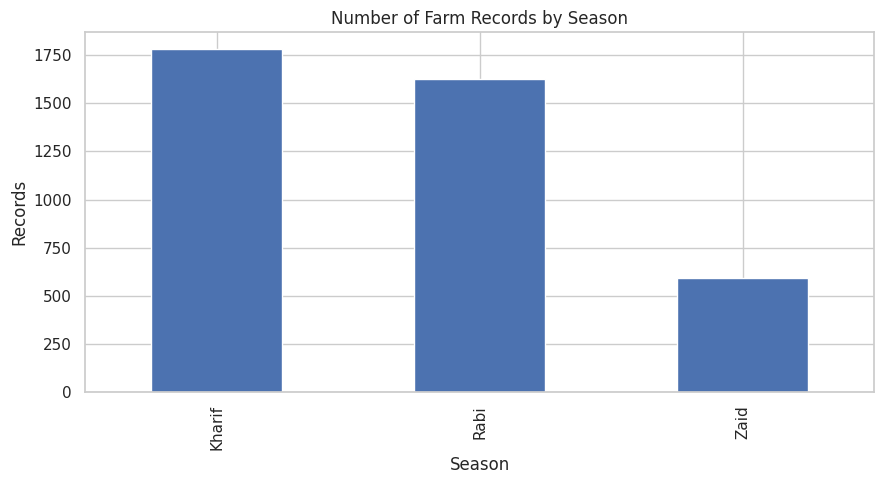

In [9]:
fig, ax = plt.subplots(figsize=(9,5))
df["Season"].value_counts().reindex(["Kharif","Rabi","Zaid"]).plot(kind="bar", ax=ax)
ax.set_title("Number of Farm Records by Season")
ax.set_xlabel("Season"); ax.set_ylabel("Records")
plt.tight_layout(); plt.show()

## 4. Seasonal Agricultural Performance — Core Analysis

In [10]:
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Yield_SD=("Yield_Tonnes_Ha","std"),
    Avg_Production=("Production_Tonnes","mean"),
    Avg_Cost=("Total_Cost_INR","mean"),
    Avg_Revenue=("Revenue_INR","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Median_Profit=("Profit_INR","median"),
    Avg_Water=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct","mean")
).reindex(["Kharif","Rabi","Zaid"]).round(2)
season_summary

,Farms,Avg_Yield,Median_Yield,Yield_SD,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit,Avg_Water,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,,,,
Kharif,1779,5.64,1.95,14.42,46.31,"531,804.41","710,719.06","178,914.65","38,808.00","6,102.20",5.89,54.47
Rabi,1627,5.08,1.66,12.83,41.49,"513,836.58","601,526.05","87,689.47","-3,187.00","5,846.99",5.19,40.48
Zaid,594,4.67,1.45,11.32,38.89,"543,976.73","519,171.90","-24,804.82","-62,144.00","6,419.89",4.41,38.22


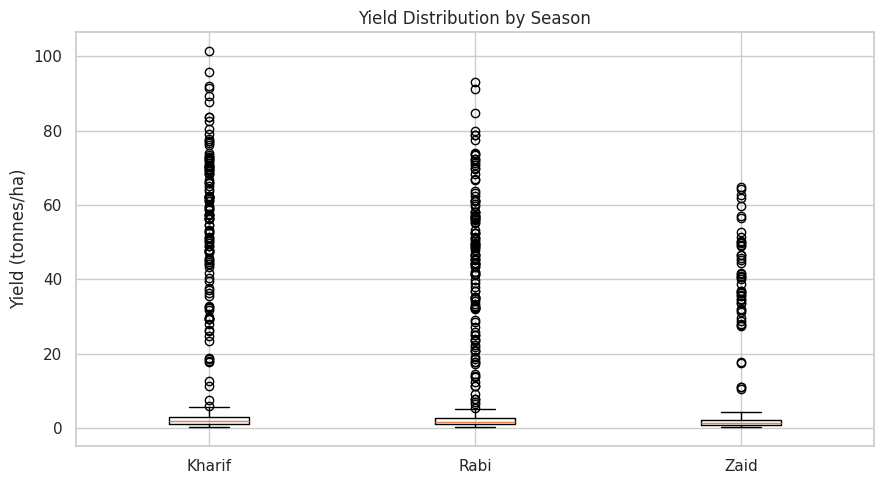

In [11]:
fig, ax=plt.subplots(figsize=(9,5))
data=[df.loc[df["Season"]==s,"Yield_Tonnes_Ha"].dropna() for s in ["Kharif","Rabi","Zaid"]]
ax.boxplot(data,labels=["Kharif","Rabi","Zaid"])
ax.set_title("Yield Distribution by Season")
ax.set_ylabel("Yield (tonnes/ha)")
plt.tight_layout(); plt.show()

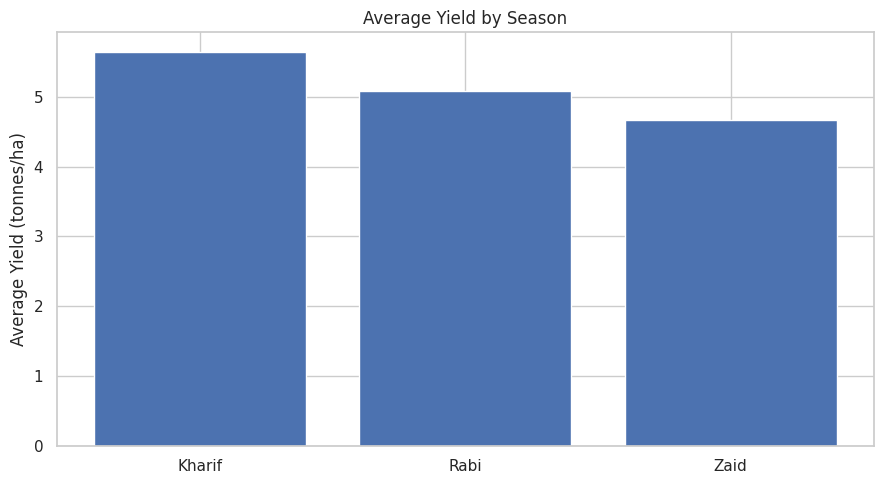

In [12]:
fig, ax = plt.subplots(figsize=(9,5))
means=df.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(["Kharif","Rabi","Zaid"])
ax.bar(means.index, means.values)
ax.set_title("Average Yield by Season")
ax.set_ylabel("Average Yield (tonnes/ha)")
plt.tight_layout(); plt.show()

## 5. Environmental Conditions by Season

In [13]:
env_cols=["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_pH","Soil_Moisture_pct"]
df.groupby("Season")[env_cols].mean().reindex(["Kharif","Rabi","Zaid"]).round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.08,28.45,71.81,6.79,6.73,31.20
Rabi,436.00,23.49,57.89,7.59,6.67,24.05
Zaid,299.42,31.04,52.01,8.18,6.69,19.17


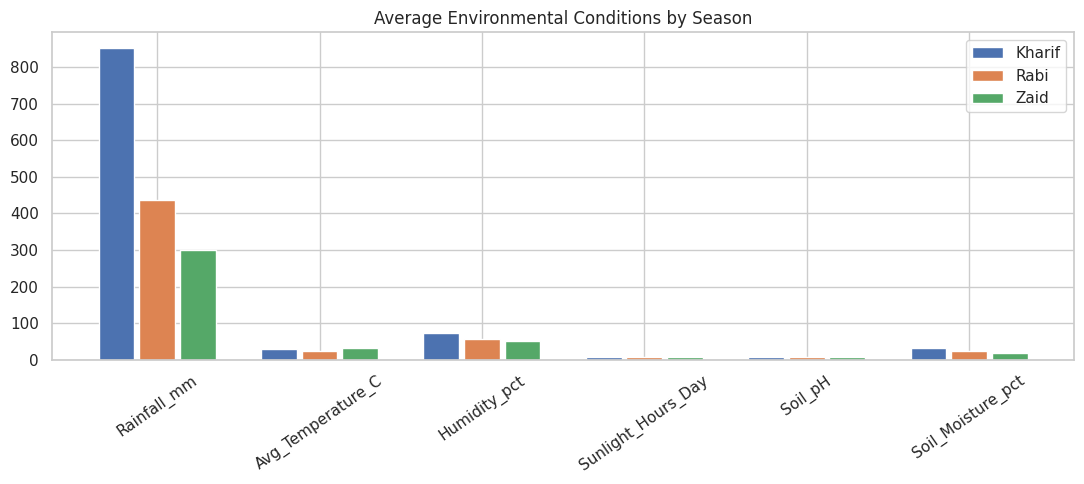

In [14]:
long = df.groupby("Season")[env_cols].mean().reindex(["Kharif","Rabi","Zaid"]).reset_index().melt("Season")
fig, ax=plt.subplots(figsize=(11,5))
for season in ["Kharif","Rabi","Zaid"]:
    vals=long[long["Season"]==season]["value"].values
    x=np.arange(len(env_cols)) + ({"Kharif":-0.25,"Rabi":0,"Zaid":0.25}[season])
    ax.bar(x, vals, width=0.22, label=season)
ax.set_xticks(np.arange(len(env_cols)))
ax.set_xticklabels(env_cols, rotation=35)
ax.set_title("Average Environmental Conditions by Season")
ax.legend()
plt.tight_layout(); plt.show()

## 6. Crop × Season Analysis

In [15]:
crop_season = df.groupby(["Crop","Season"]).agg(
    Farms=("Farm_ID","count"),
    Mean_Yield=("Yield_Tonnes_Ha","mean"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Mean_Profit=("Profit_INR","mean"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).round(2)
crop_season.sort_values("Median_Yield",ascending=False).head(20)

Farms  Mean_Yield  Median_Yield  Mean_Profit  \
Crop      Season                                                 
Sugarcane Kharif    125       53.46         56.65 1,000,790.81   
          Rabi      129       43.94         45.46   731,612.86   
          Zaid       51       38.42         38.78   583,635.80   
Maize     Kharif    234        2.97          3.12   -39,332.67   
Rice      Kharif    314        2.71          2.88   -64,903.40   
Maize     Rabi      233        2.61          2.82   -89,133.40   
Rice      Rabi      274        2.33          2.38   -98,427.87   
Wheat     Kharif    292        2.26          2.36  -105,871.87   
Maize     Zaid       84        2.30          2.27  -194,049.17   
Wheat     Rabi      237        2.06          2.22  -119,954.57   
Rice      Zaid      102        1.90          1.94  -227,239.34   
Wheat     Zaid       85        1.75          1.84  -193,208.95   
Chilli    Kharif    185        1.73          1.78   954,380.42   
          Rabi      163        1.46          1.56   638,572.50   
Groundnut Kharif    193        1.48          1.52   108,265.44   
Cotton    Kharif    215        1.37          1.44   216,999.55   
Groundnut Rabi      177        1.22          1.29    10,416.54   
Chilli    Zaid       64        1.18          1.22   448,659.09   
Cotton    Rabi      201        1.19          1.20   107,343.59   
Groundnut Zaid       54        1.04          1.10   -68,872.50   

                  Mean_Water_Efficiency  
Crop      Season                         
Sugarcane Kharif                  36.00  
          Rabi                    27.92  
          Zaid                    23.39  
Maize     Kharif                   6.05  
Rice      Kharif                   2.17  
Maize     Rabi                     5.46  
Rice      Rabi                     1.84  
Wheat     Kharif                   4.76  
Maize     Zaid                     4.75  
Wheat     Rabi                     4.69  
Rice      Zaid                     1.53  
Wheat     Zaid                     4.02  
Chilli    Kharif                   3.26  
          Rabi                     2.89  
Groundnut Kharif                   3.58  
Cotton    Kharif                   2.13  
Groundnut Rabi                     2.90  
Chilli    Zaid                     2.20  
Cotton    Rabi                     1.94  
Groundnut Zaid                     2.47

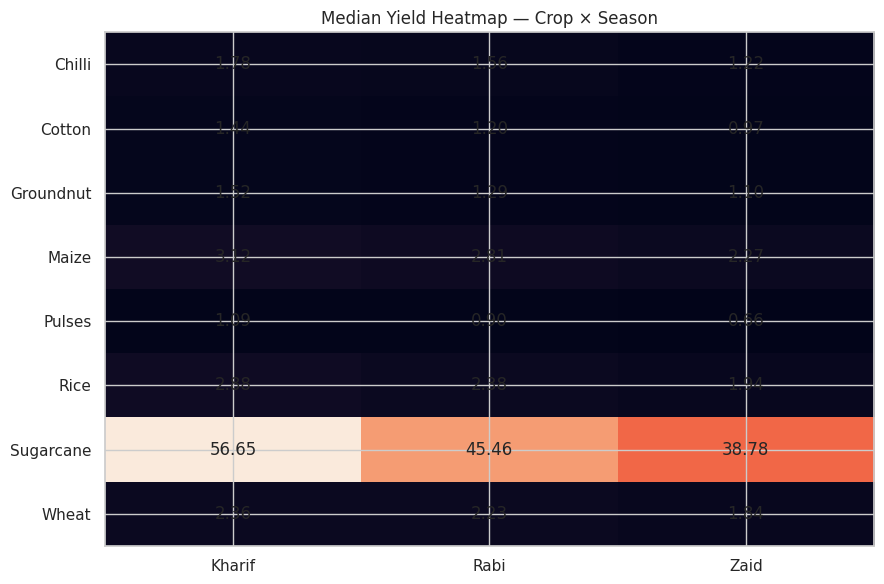

In [16]:
piv=df.pivot_table(index="Crop",columns="Season",values="Yield_Tonnes_Ha",aggfunc="median").reindex(columns=["Kharif","Rabi","Zaid"])
fig, ax=plt.subplots(figsize=(9,6))
im=ax.imshow(piv.values, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        if pd.notna(piv.iloc[i,j]): ax.text(j,i,f"{piv.iloc[i,j]:.2f}",ha="center",va="center")
ax.set_title("Median Yield Heatmap — Crop × Season")
plt.tight_layout(); plt.show()

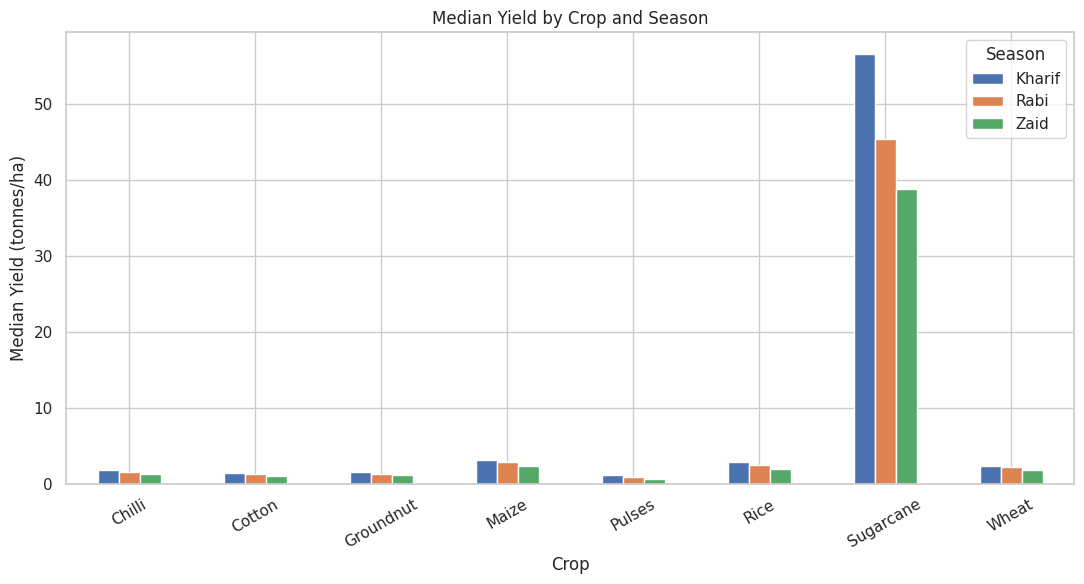

In [17]:
fig, ax=plt.subplots(figsize=(11,6))
p=df.groupby(["Crop","Season"])["Yield_Tonnes_Ha"].median().unstack().reindex(columns=["Kharif","Rabi","Zaid"])
p.plot(kind="bar",ax=ax)
ax.set_title("Median Yield by Crop and Season")
ax.set_ylabel("Median Yield (tonnes/ha)")
ax.tick_params(axis="x",rotation=30)
plt.tight_layout(); plt.show()

## 7. District / Regional Analysis

In [18]:
district_season=df.groupby(["District","Season"]).agg(
    Farms=("Farm_ID","count"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Mean_Profit=("Profit_INR","mean"),
    Mean_Water=("Water_Used_m3","mean"),
    Mean_Disease_Risk=("Disease_Pest_Risk_pct","mean")
).round(2)
district_season.head(20)

Farms  Median_Yield  Mean_Profit  Mean_Water  \
District Season                                                 
Erode    Kharif    179          1.98   150,975.39    6,651.30   
         Rabi      154          1.52   126,599.00    5,930.07   
         Zaid       70          1.17   -76,896.79    5,988.77   
Guntur   Kharif    180          1.56   173,269.48    5,280.96   
         Rabi      153          1.67    94,113.28    6,424.81   
         Zaid       57          1.71    -3,287.47    6,599.25   
Indore   Kharif    183          1.95   189,966.01    6,804.60   
         Rabi      154          1.67    35,897.42    5,862.24   
         Zaid       55          1.29   -88,123.95    5,427.89   
Krishna  Kharif    183          2.06   154,541.10    6,090.75   
         Rabi      159          1.60    31,757.33    5,592.63   
         Zaid       51          1.42   -50,622.78    5,480.57   
Ludhiana Kharif    170          1.98   155,036.61    5,802.12   
         Rabi      190          1.60    90,916.95    5,934.69   
         Zaid       67          1.50   -92,972.51    7,383.99   
Nalgonda Kharif    172          2.25   187,674.79    6,503.50   
         Rabi      177          1.67    89,453.61    5,534.40   
         Zaid       66          1.70    95,513.17    7,895.26   
Nashik   Kharif    167          2.08   146,776.94    5,720.35   
         Rabi      145          1.50    72,051.18    5,507.64   

                 Mean_Disease_Risk  
District Season                     
Erode    Kharif              55.24  
         Rabi                40.03  
         Zaid                38.45  
Guntur   Kharif              52.93  
         Rabi                40.14  
         Zaid                37.88  
Indore   Kharif              55.78  
         Rabi                40.29  
         Zaid                37.13  
Krishna  Kharif              53.70  
         Rabi                40.28  
         Zaid                38.57  
Ludhiana Kharif              55.46  
         Rabi                41.48  
         Zaid                38.52  
Nalgonda Kharif              53.87  
         Rabi                39.01  
         Zaid                38.27  
Nashik   Kharif              55.92  
         Rabi                40.12

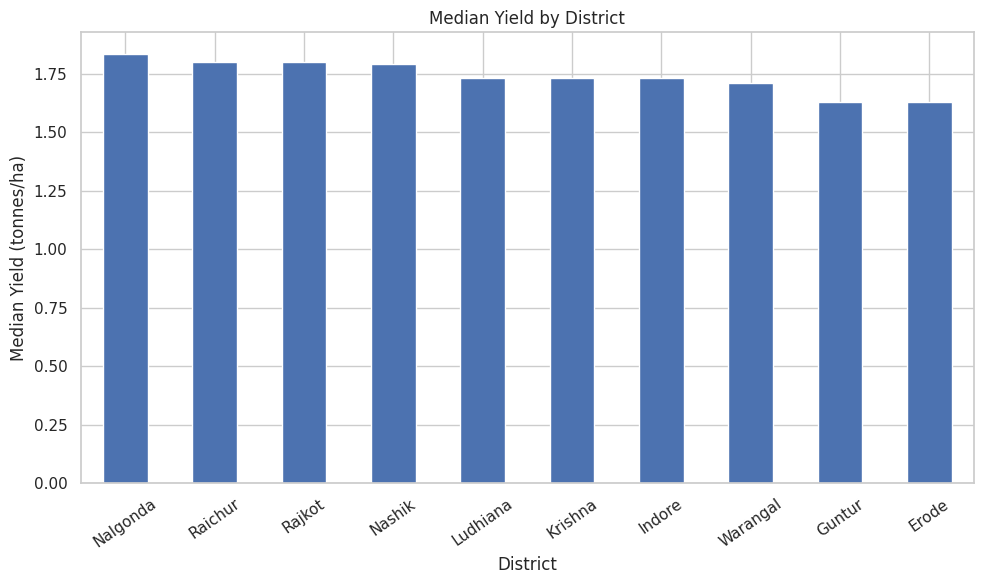

In [19]:
dmed=df.groupby("District")["Yield_Tonnes_Ha"].median().sort_values(ascending=False)
fig, ax=plt.subplots(figsize=(10,6))
dmed.plot(kind="bar",ax=ax)
ax.set_title("Median Yield by District"); ax.set_ylabel("Median Yield (tonnes/ha)")
ax.tick_params(axis="x",rotation=35)
plt.tight_layout(); plt.show()

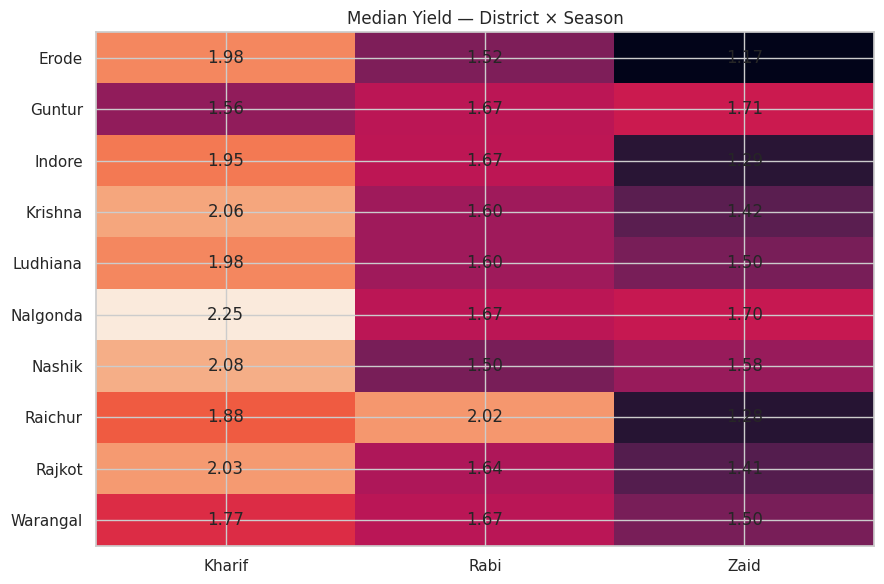

In [20]:
dp=df.pivot_table(index="District",columns="Season",values="Yield_Tonnes_Ha",aggfunc="median").reindex(columns=["Kharif","Rabi","Zaid"])
fig, ax=plt.subplots(figsize=(9,6))
im=ax.imshow(dp.values, aspect="auto")
ax.set_xticks(range(len(dp.columns))); ax.set_xticklabels(dp.columns)
ax.set_yticks(range(len(dp.index))); ax.set_yticklabels(dp.index)
for i in range(dp.shape[0]):
    for j in range(dp.shape[1]):
        if pd.notna(dp.iloc[i,j]): ax.text(j,i,f"{dp.iloc[i,j]:.2f}",ha="center",va="center")
ax.set_title("Median Yield — District × Season")
plt.tight_layout(); plt.show()

## 8. Geographic Map

The CSV does **not** contain farm-level latitude/longitude. Also, district names occur across multiple states in the supplied records, so state–district relationships should not be treated as validated geographic data.

The map therefore uses **representative district reference coordinates only**. It is a visualization aid, not a farm-location map.

In [21]:
district_coords={
"Rajkot":(22.3039,70.8022),"Nalgonda":(17.0575,79.2671),"Warangal":(17.9689,79.5941),
"Indore":(22.7196,75.8577),"Ludhiana":(30.9010,75.8573),"Raichur":(16.2120,77.3439),
"Guntur":(16.3067,80.4365),"Krishna":(16.1875,81.1389),"Nashik":(19.9975,73.7898),
"Erode":(11.3410,77.7172)}

map_df=df.groupby("District").agg(Median_Yield=("Yield_Tonnes_Ha","median"),
                                  Avg_Profit=("Profit_INR","mean"),
                                  Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
                                  Farms=("Farm_ID","count")).reset_index()
map_df["Latitude"]=map_df["District"].map(lambda x: district_coords[x][0])
map_df["Longitude"]=map_df["District"].map(lambda x: district_coords[x][1])

m=folium.Map(location=[20.5,78.9],zoom_start=5,tiles="OpenStreetMap")
for _,r in map_df.iterrows():
    popup=(f"<b>{r['District']}</b><br>Farms: {int(r['Farms'])}"
           f"<br>Median Yield: {r['Median_Yield']:.2f} t/ha"
           f"<br>Average Profit: ₹{r['Avg_Profit']:,.0f}"
           f"<br>Water Efficiency: {r['Avg_Water_Efficiency']:.2f} t/1000m³")
    folium.CircleMarker([r["Latitude"],r["Longitude"]],radius=7,fill=True,
                        tooltip=f"{r['District']} — {r['Median_Yield']:.2f} t/ha",
                        popup=folium.Popup(popup,max_width=300)).add_to(m)
display(m)

## 9. Irrigation & Resource Usage

In [22]:
resource_summary=df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","count"), Median_Yield=("Yield_Tonnes_Ha","median"),
    Median_Water=("Water_Used_m3","median"),
    Median_Water_Efficiency=("Water_Efficiency_t_per_1000m3","median"),
    Mean_Fertilizer=("Fertilizer_kg_ha","mean"),
    Mean_Pesticide=("Pesticide_Litre_ha","mean"),
    Mean_Profit=("Profit_INR","mean")
).round(2)
resource_summary

,Farms,Median_Yield,Median_Water,Median_Water_Efficiency,Mean_Fertilizer,Mean_Pesticide,Mean_Profit
Irrigation_Method,,,,,,,
Drip,915,1.96,"4,606.00",3.26,186.28,5.16,"219,626.00"
Flood,1310,1.63,"6,326.00",1.95,185.76,5.10,"73,354.02"
Rainfed,1041,1.72,"2,782.00",4.58,186.88,4.98,"79,050.37"
Sprinkler,734,1.80,"4,687.00",2.65,185.03,5.03,"91,121.08"


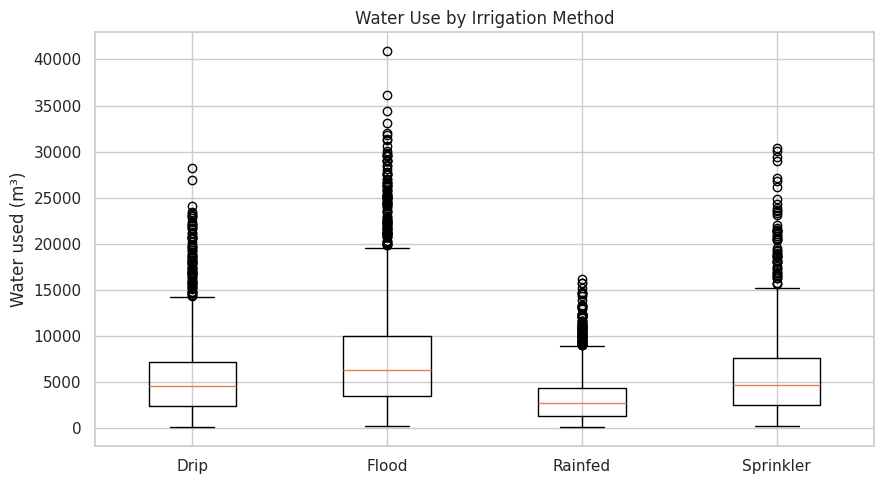

In [23]:
fig, ax=plt.subplots(figsize=(9,5))
methods=list(df["Irrigation_Method"].dropna().unique())
data=[df.loc[df["Irrigation_Method"]==m,"Water_Used_m3"].dropna() for m in methods]
ax.boxplot(data,labels=methods)
ax.set_title("Water Use by Irrigation Method")
ax.set_ylabel("Water used (m³)")
plt.tight_layout(); plt.show()

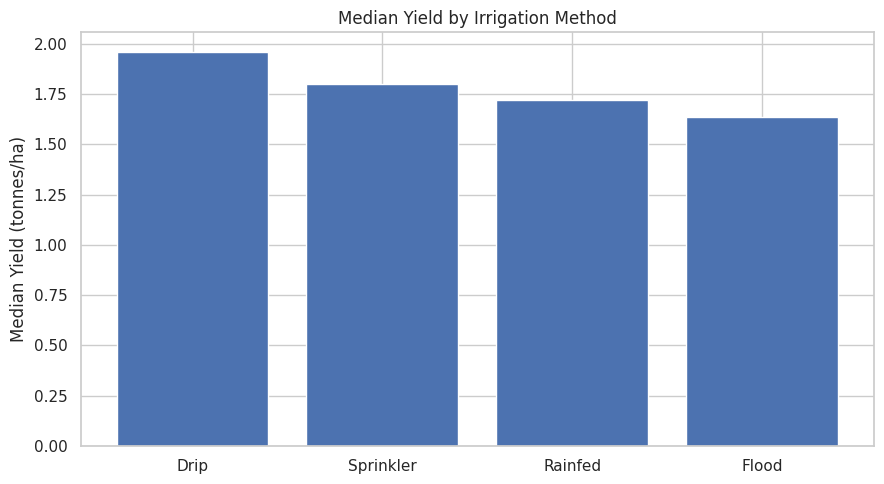

In [24]:
fig, ax=plt.subplots(figsize=(9,5))
irr=df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].median().sort_values(ascending=False)
ax.bar(irr.index,irr.values)
ax.set_title("Median Yield by Irrigation Method")
ax.set_ylabel("Median Yield (tonnes/ha)")
plt.tight_layout(); plt.show()

## 10. Economic Performance

In [25]:
econ=df.groupby("Season").agg(
    Avg_Cost=("Total_Cost_INR","mean"), Avg_Revenue=("Revenue_INR","mean"),
    Avg_Profit=("Profit_INR","mean"), Median_Profit=("Profit_INR","median")
).reindex(["Kharif","Rabi","Zaid"]).round(2)
econ

,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit
Season,,,,
Kharif,"531,804.41","710,719.06","178,914.65","38,808.00"
Rabi,"513,836.58","601,526.05","87,689.47","-3,187.00"
Zaid,"543,976.73","519,171.90","-24,804.82","-62,144.00"


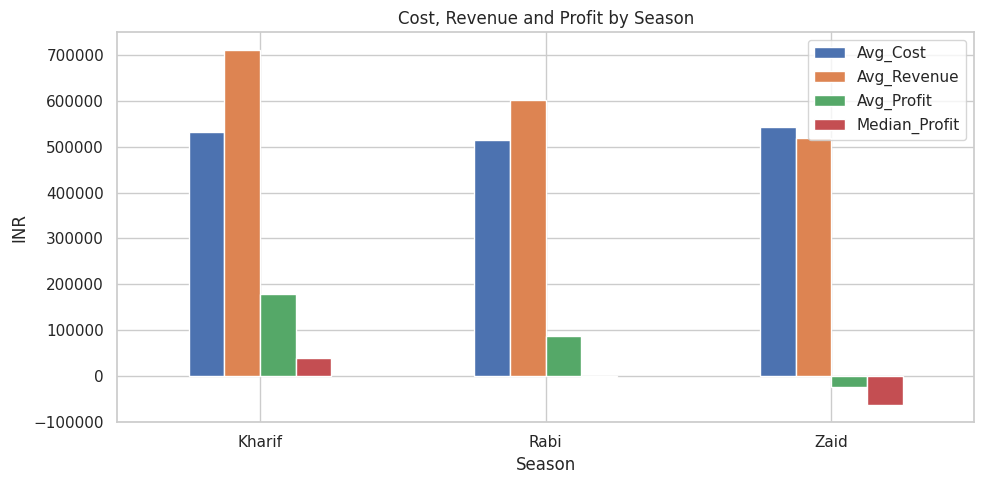

In [26]:
fig, ax=plt.subplots(figsize=(10,5))
econ.plot(kind="bar",ax=ax)
ax.set_title("Cost, Revenue and Profit by Season")
ax.set_ylabel("INR")
ax.tick_params(axis="x",rotation=0)
plt.tight_layout(); plt.show()

In [27]:
df["ROI_pct"]=(df["Profit_INR"]/df["Total_Cost_INR"]*100).replace([np.inf,-np.inf],np.nan)
roi=df.groupby("Season")["ROI_pct"].agg(["mean","median"]).reindex(["Kharif","Rabi","Zaid"]).round(2)
roi

,mean,median
Season,,
Kharif,35.45,12.47
Rabi,17.60,-1.32
Zaid,-2.47,-19.73


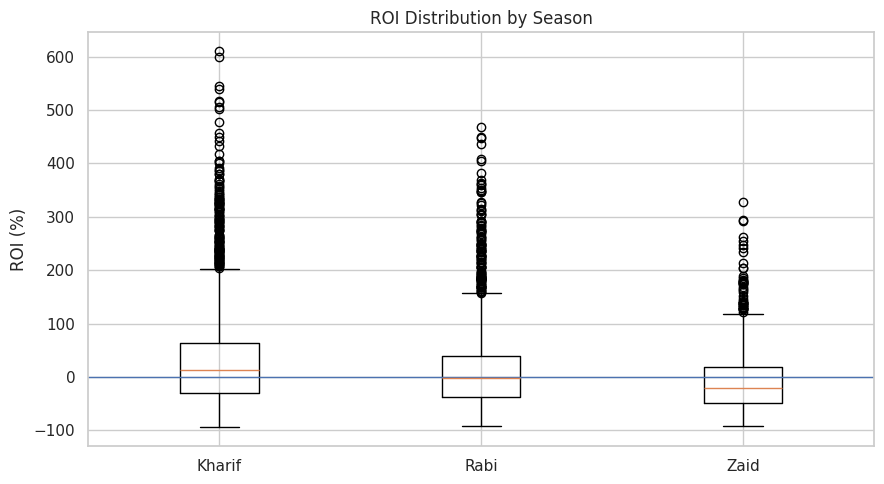

In [28]:
fig, ax=plt.subplots(figsize=(9,5))
data=[df.loc[df["Season"]==s,"ROI_pct"].dropna() for s in ["Kharif","Rabi","Zaid"]]
ax.boxplot(data,labels=["Kharif","Rabi","Zaid"])
ax.axhline(0,linewidth=1)
ax.set_title("ROI Distribution by Season")
ax.set_ylabel("ROI (%)")
plt.tight_layout(); plt.show()

## 11. Correlation & Relationship Analysis

In [29]:
relationship_cols=[
"Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_pH",
"Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha","Potassium_kg_ha",
"Fertilizer_kg_ha","Pesticide_Litre_ha","Seed_Quality_Score","Water_Used_m3",
"Disease_Pest_Risk_pct","Market_Price_INR_Tonne"]
yield_corr=df[relationship_cols+["Yield_Tonnes_Ha"]].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()
yield_corr.to_frame("Correlation with Yield")

,Correlation with Yield
Market_Price_INR_Tonne,-0.38
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Pesticide_Litre_ha,-0.01
Seed_Quality_Score,-0.01
Fertilizer_kg_ha,0.00
Potassium_kg_ha,0.00
Avg_Temperature_C,0.01
Soil_Moisture_pct,0.01
Humidity_pct,0.01


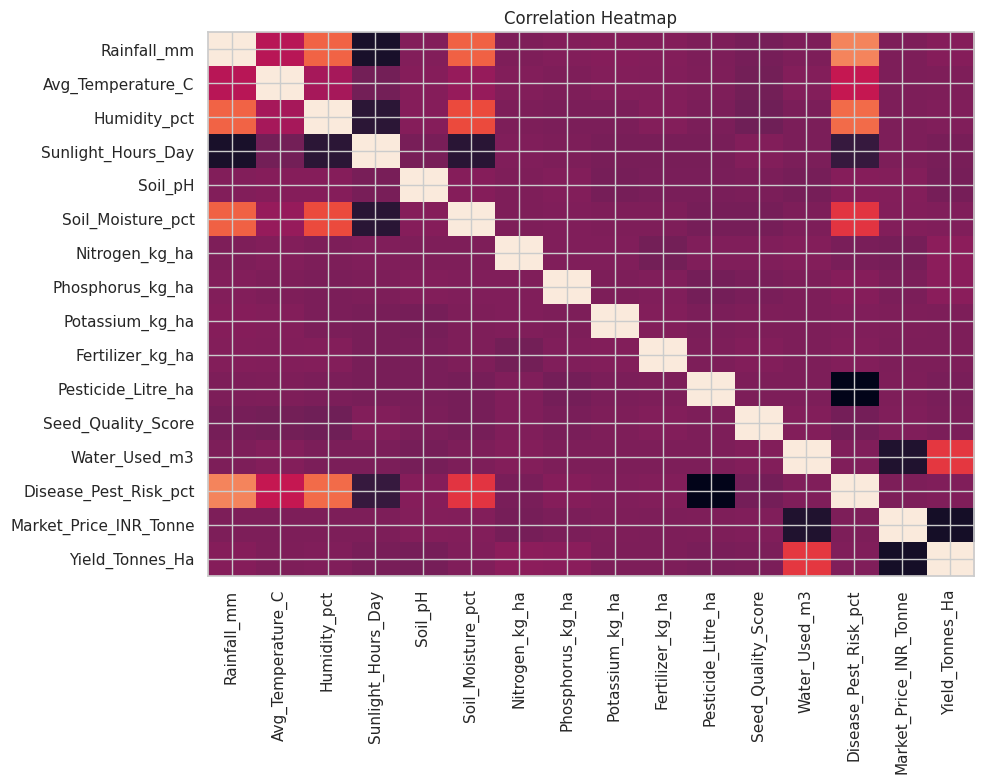

In [30]:
corr=df[relationship_cols+["Yield_Tonnes_Ha"]].corr()
fig, ax=plt.subplots(figsize=(10,8))
im=ax.imshow(corr.values,aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns,rotation=90)
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

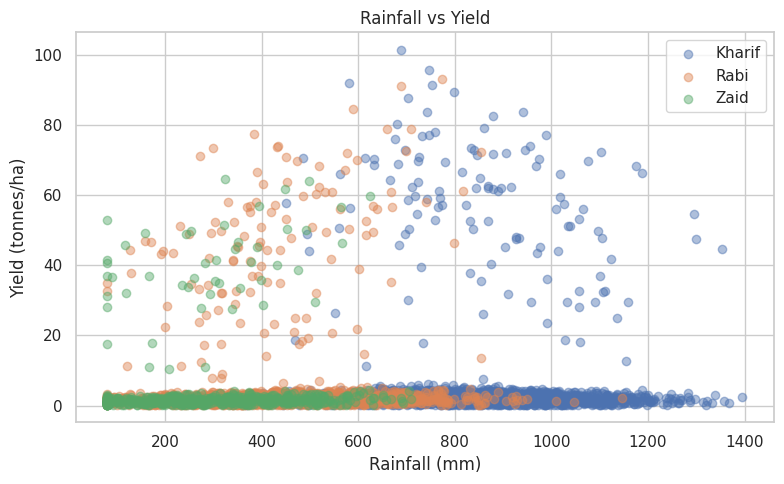

In [31]:
fig, ax=plt.subplots(figsize=(8,5))
for season in ["Kharif","Rabi","Zaid"]:
    d=df[df["Season"]==season]
    ax.scatter(d["Rainfall_mm"],d["Yield_Tonnes_Ha"],alpha=.45,label=season)
ax.set_title("Rainfall vs Yield"); ax.set_xlabel("Rainfall (mm)"); ax.set_ylabel("Yield (tonnes/ha)")
ax.legend()
plt.tight_layout(); plt.show()

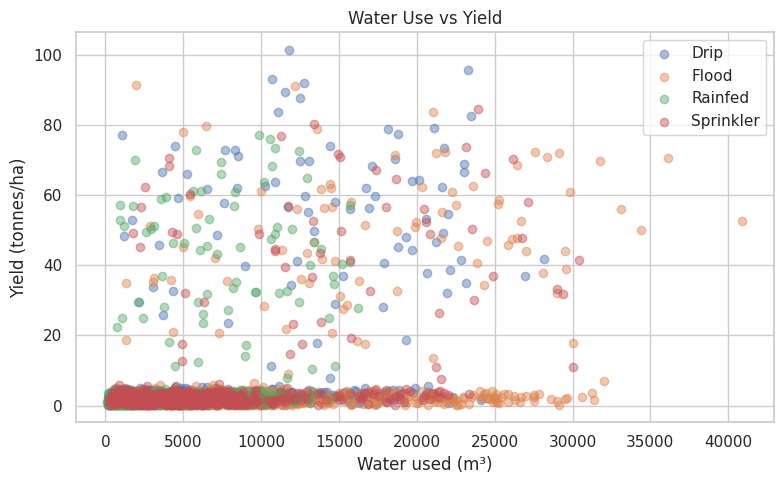

In [32]:
fig, ax=plt.subplots(figsize=(8,5))
for method in sorted(df["Irrigation_Method"].dropna().unique()):
    d=df[df["Irrigation_Method"]==method]
    ax.scatter(d["Water_Used_m3"],d["Yield_Tonnes_Ha"],alpha=.45,label=method)
ax.set_title("Water Use vs Yield"); ax.set_xlabel("Water used (m³)"); ax.set_ylabel("Yield (tonnes/ha)")
ax.legend()
plt.tight_layout(); plt.show()

**Important:** Water efficiency is mathematically constructed from yield and water use, so its high correlation with yield is expected and must not be interpreted as independent causal evidence.

## 12. Statistical Testing

In [33]:
groups=[g["Yield_Tonnes_Ha"].dropna().values for _,g in df.groupby("Season")]
H,p=stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {H:.4f}")
print(f"p-value = {p:.6g}")
print("Conclusion:", "Statistically significant seasonal difference at α=0.05." if p<0.05 else "No statistically significant seasonal difference at α=0.05.")

Kruskal-Wallis H = 68.6043
p-value = 1.26697e-15
Conclusion: Statistically significant seasonal difference at α=0.05.


In [34]:
seasons=["Kharif","Rabi","Zaid"]
rows=[]
for i in range(len(seasons)):
    for j in range(i+1,len(seasons)):
        a=df.loc[df.Season==seasons[i],"Yield_Tonnes_Ha"].dropna()
        b=df.loc[df.Season==seasons[j],"Yield_Tonnes_Ha"].dropna()
        u,p=stats.mannwhitneyu(a,b,alternative="two-sided")
        rows.append([seasons[i],seasons[j],u,p])
pairwise=pd.DataFrame(rows,columns=["Season A","Season B","U statistic","Raw p-value"])
pairwise["Bonferroni p-value"]=(pairwise["Raw p-value"]*len(pairwise)).clip(upper=1)
pairwise

,Season A,Season B,U statistic,Raw p-value,Bonferroni p-value
0,Kharif,Rabi,"1,568,847.50",0.00,0.00
1,Kharif,Zaid,"633,975.50",0.00,0.00
2,Rabi,Zaid,"528,776.00",0.00,0.00


## 13. Outlier & Anomaly Analysis

In [35]:
def iqr_report(s):
    x=s.dropna(); q1=x.quantile(.25); q3=x.quantile(.75); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    return pd.Series({"outliers":int(((s<lo)|(s>hi)).sum()),"lower_bound":lo,"upper_bound":hi})
out=pd.DataFrame({c:iqr_report(df[c]) for c in ["Yield_Tonnes_Ha","Production_Tonnes","Profit_INR","Water_Used_m3","Market_Price_INR_Tonne"]}).T
out.round(2)

,outliers,lower_bound,upper_bound
Yield_Tonnes_Ha,302.00,-1.63,5.52
Production_Tonnes,333.00,-23.98,53.36
Profit_INR,404.00,"-696,111.00","763,567.00"
Water_Used_m3,276.00,"-6,072.75","16,171.25"
Market_Price_INR_Tonne,0.00,"-48,845.38","138,553.62"


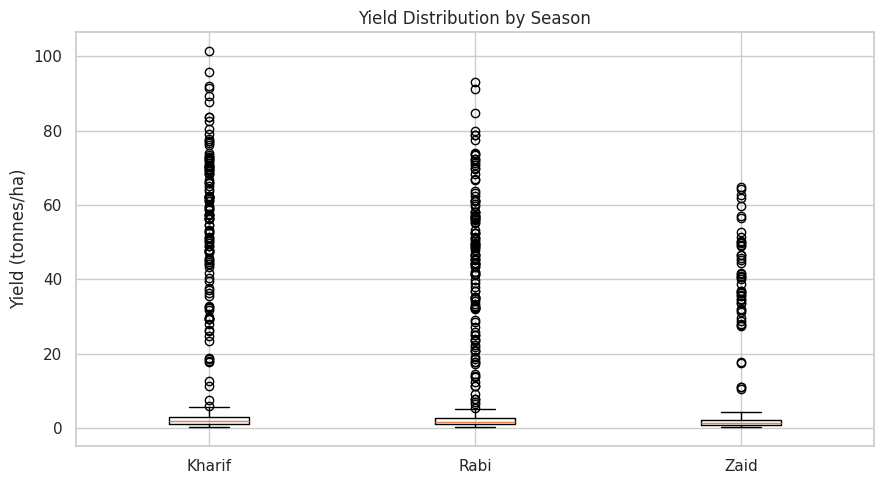

In [36]:
fig, ax=plt.subplots(figsize=(9,5))
data=[df.loc[df["Season"]==s,"Yield_Tonnes_Ha"].dropna() for s in ["Kharif","Rabi","Zaid"]]
ax.boxplot(data,labels=["Kharif","Rabi","Zaid"])
ax.set_title("Yield Distribution by Season")
ax.set_ylabel("Yield (tonnes/ha)")
plt.tight_layout(); plt.show()

In [37]:
df[["Farm_ID","State","District","Crop","Season","Yield_Tonnes_Ha","Production_Tonnes","Profit_INR"]].sort_values("Yield_Tonnes_Ha",ascending=False).head(10)

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44,641.10,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,"1,424.40",3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13,648.18,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98,703.65,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46,75.00,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32,522.35,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76,672.24,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,"1,249.21",3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,1200815


Outliers are **flagged, not automatically removed**. Extreme values can represent real agricultural conditions or data problems and should be investigated before exclusion.

## 14. Seasonal Consistency

In [38]:
crop_piv=df.pivot_table(index="Crop",columns="Season",values="Yield_Tonnes_Ha",aggfunc="median").reindex(columns=seasons)
crop_piv["Seasonal_Range"]=crop_piv.max(axis=1)-crop_piv.min(axis=1)
crop_piv.sort_values("Seasonal_Range",ascending=False)

Season,Kharif,Rabi,Zaid,Seasonal_Range
Crop,,,,
Sugarcane,56.65,45.46,38.78,17.87
Rice,2.88,2.38,1.94,0.94
Maize,3.12,2.81,2.27,0.85
Chilli,1.78,1.56,1.22,0.56
Wheat,2.36,2.23,1.84,0.52
Cotton,1.44,1.20,0.97,0.47
Pulses,1.09,0.90,0.66,0.43
Groundnut,1.52,1.29,1.10,0.42


In [39]:
district_piv=df.pivot_table(index="District",columns="Season",values="Yield_Tonnes_Ha",aggfunc="median").reindex(columns=seasons)
district_piv["Seasonal_Range"]=district_piv.max(axis=1)-district_piv.min(axis=1)
district_piv.sort_values("Seasonal_Range",ascending=False)

Season,Kharif,Rabi,Zaid,Seasonal_Range
District,,,,
Erode,1.98,1.52,1.17,0.81
Raichur,1.88,2.02,1.28,0.74
Indore,1.95,1.67,1.29,0.66
Krishna,2.06,1.60,1.42,0.64
Rajkot,2.03,1.64,1.41,0.62
Nashik,2.08,1.50,1.58,0.58
Nalgonda,2.25,1.67,1.70,0.58
Ludhiana,1.98,1.60,1.50,0.48
Warangal,1.77,1.67,1.50,0.27


## 15. Evidence-Based Findings

In [40]:
best_yield=season_summary["Median_Yield"].idxmax()
worst_yield=season_summary["Median_Yield"].idxmin()
best_profit=season_summary["Avg_Profit"].idxmax()
best_cs=crop_season.sort_values("Median_Yield",ascending=False).iloc[0]
best_irrigation=resource_summary["Median_Yield"].idxmax()

findings=pd.Series({
"Highest median-yield season":best_yield,
"Lowest median-yield season":worst_yield,
"Highest average-profit season":best_profit,
"Highest median-yield crop-season":f"{best_cs.name[0]} — {best_cs.name[1]}",
"Highest median-yield irrigation method":best_irrigation,
"Records analyzed":len(df),
"Total missing cells retained":int(df.isna().sum().sum())
},name="Finding")
findings

Highest median-yield season                           Kharif
Lowest median-yield season                              Zaid
Highest average-profit season                         Kharif
Highest median-yield crop-season          Sugarcane — Kharif
Highest median-yield irrigation method                  Drip
Records analyzed                                        4000
Total missing cells retained                             120
Name: Finding, dtype: object

## 16. Final Interpretation & Recommendations

### Interpretation framework
Use the notebook outputs as **Observation → Evidence → Interpretation → Implication**.

### Recommendations
1. **Seasonal planning:** compare productivity and profitability together before prioritizing a season.
2. **Crop-season matching:** investigate the strongest crop-season combinations and their environmental/resource conditions.
3. **Resource optimization:** evaluate irrigation and water use alongside yield rather than maximizing inputs.
4. **Risk management:** monitor high disease/pest-risk groups and unstable crop/district combinations.
5. **Economic planning:** consider profit/ROI, not yield alone.
6. **Data-quality improvement:** collect validated state–district mappings and farm-level coordinates.
7. **Future data collection:** add multiple years, actual weather time series and farm geospatial data to support stronger trend and causal analysis.

### Important limitations
- There is no explicit year/time field, so year-over-year trends cannot be established.
- There are no farm-level coordinates; the map uses representative district reference points.
- District names occur across multiple states in the supplied records, so state-level geographic conclusions are unreliable without validation.
- Correlation does not prove causation.
- Water efficiency is mathematically related to yield and water use.